# Data Loading

In [1]:
import pandas as pd
import numpy as np
import ast
import re

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from collections import Counter
from itertools import combinations

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import shap

from IPython.display import display

In [2]:
# Main international job postings dataset
jobs = pd.read_csv("data_jobs.csv")

# Philippine local dataset (reserved for later external validation)
lfs = pd.read_csv("FIES2015 - LFSJAN16 CSV - Cleaned.csv", low_memory=False)

# World Bank country-level context data
econ = pd.read_csv("world_bank_data_2025.csv")

print("jobs shape:", jobs.shape)
print("lfs shape:", lfs.shape)
print("econ shape:", econ.shape)

display(jobs.head())

jobs shape: (785741, 17)
lfs shape: (207212, 154)
econ shape: (3472, 16)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


# Data Preprocessing

In [3]:
# -------------------------
# COUNTRY STANDARDIZATION
# -------------------------
country_map = {
    "Russia": "Russian Federation",
    "Vietnam": "Viet Nam",
    "South Korea": "Korea, Rep.",
    "North Korea": "Korea, Dem. People's Rep.",
    "Egypt": "Egypt, Arab Rep.",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Iran": "Iran, Islamic Rep.",
    "Venezuela": "Venezuela, RB",
    "Slovakia": "Slovak Republic",
    "Hong Kong": "Hong Kong SAR, China",
    "Macedonia (FYROM)": "North Macedonia",
    "Palestine": "West Bank and Gaza",
    "Laos": "Lao PDR",
    "Syria": "Syrian Arab Republic",
    "Turkey": "Turkiye",
    "Yemen": "Yemen, Rep.",
    "United States Virgin Islands": "Virgin Islands (U.S.)",
    "Bahamas": "Bahamas, The",
    "Brunei": "Brunei Darussalam",
    "Congo, Democratic Republic of the": "Congo, Dem. Rep.",
    "Curaçao": "Curacao",
    "Gambia": "Gambia, The",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Taiwan": "Taiwan, China",
    "U.S. Virgin Islands": "Virgin Islands (U.S.)"
}

In [4]:
# -------------------------
# WORLD BANK 2023 FEATURES
# -------------------------
econ_2023 = econ[econ["year"] == 2023].copy()

econ_2023 = econ_2023[[
    "country_name",
    "GDP per Capita (Current USD)",
    "GDP (Current USD)",
    "Unemployment Rate (%)",
    "Inflation (CPI %)",
    "GDP Growth (% Annual)"
]]

# interest rate, gross national income (USD)

econ_2023.columns = [
    "country",
    "gdp_per_capita",
    "gdp",
    "unemployment",
    "inflation",
    "gdp_growth"
]

display(econ_2023.head())

,country,gdp_per_capita,gdp,unemployment,inflation,gdp_growth
13,Aruba,33984.790620,3.648573e+09,NaN,NaN,4.263719
29,Afghanistan,415.707417,1.723305e+10,13.991,-4.644709,2.710887
45,Angola,2308.159767,8.482465e+10,14.537,13.644102,1.001289
61,Albania,8575.171134,2.354718e+10,10.108,4.759764,3.936625
77,Andorra,46812.448449,3.785067e+09,NaN,NaN,2.583555


In [5]:
# -------------------------
# KEEP USEFUL COLUMNS
# -------------------------
wanted_cols = [
    "job_title_short",
    "job_title",
    "job_location",
    "job_via",
    "job_schedule_type",
    "job_work_from_home",
    "job_no_degree_mention",
    "job_health_insurance",
    "job_country",
    "salary_rate",
    "salary_year_avg",
    "salary_hour_avg",
    "company_name",
    "job_skills",
    "job_type_skills"
]

existing_cols = [c for c in wanted_cols if c in jobs.columns]

jobs_model = jobs[existing_cols].copy()

# standardize country names
jobs_model["job_country"] = jobs_model["job_country"].replace(country_map)

# filter to North America
jobs_model = jobs_model[jobs_model["job_country"].isin([
    "United States", "Canada"
])].copy()

print("Shape after NA filter:", jobs_model.shape)

# merge economic features
jobs_model = jobs_model.merge(
    econ_2023,
    left_on="job_country",
    right_on="country",
    how="left"
)

# fill numeric macroeconomic missings with median
for col in ["gdp_per_capita", "gdp", "unemployment", "inflation", "gdp_growth"]:
    if col in jobs_model.columns:
        jobs_model[col] = jobs_model[col].fillna(jobs_model[col].median())

print("jobs_model shape after merge:", jobs_model.shape)
display(jobs_model.head())

Shape after NA filter: (222321, 15)
jobs_model shape after merge: (222321, 21)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,salary_hour_avg,company_name,job_skills,job_type_skills,country,gdp_per_capita,gdp,unemployment,inflation,gdp_growth
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,False,False,United States,NaN,...,NaN,Boehringer Ingelheim,NaN,NaN,United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
1,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,True,False,United States,NaN,...,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
2,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,False,False,United States,NaN,...,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '...",United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
3,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,False,False,United States,NaN,...,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['...",United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
4,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,False,False,United States,NaN,...,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'...",United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556


In [6]:
print(jobs_model["job_country"].value_counts())

job_country
United States    206292
Canada            16029
Name: count, dtype: int64


In [7]:
# -------------------------
# TARGET SALARY
# -------------------------
def get_salary(row):
    if pd.notna(row.get("salary_year_avg")):
        return row["salary_year_avg"]
    if pd.notna(row.get("salary_hour_avg")):
        return row["salary_hour_avg"] * 40 * 52
    return np.nan

jobs_model["salary"] = jobs_model.apply(get_salary, axis=1)
jobs_model = jobs_model.dropna(subset=["salary"]).copy()

print("Shape after removing missing salaries:", jobs_model.shape)

Shape after removing missing salaries: (25685, 22)


In [8]:
# remove salary outliers (IQR)
Q1 = jobs_model["salary"].quantile(0.25)
Q3 = jobs_model["salary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

jobs_model = jobs_model[
    (jobs_model["salary"] >= lower) &
    (jobs_model["salary"] <= upper)
].copy()

jobs_model["salary_log"] = np.log1p(jobs_model["salary"])

print("Shape after outlier removal:", jobs_model.shape)
print("Salary summary:")
display(jobs_model["salary"].describe())

Shape after outlier removal: (25176, 23)
Salary summary:


count     25176.000000
mean     112131.955287
std       42085.044017
min       16640.000000
25%       82500.000000
50%      110219.203491
75%      140000.000000
max      231000.000000
Name: salary, dtype: float64

In [9]:
# -------------------------
# ADD ENGINEERED ECON FEATURES
# -------------------------
jobs_model["gdp_per_capita_log"] = np.log1p(jobs_model["gdp_per_capita"])
jobs_model["gdp_log"] = np.log1p(jobs_model["gdp"])
jobs_model["labor_market_tightness"] = 1 - jobs_model["unemployment"]
jobs_model["real_gdp_per_capita"] = jobs_model["gdp_per_capita"] / (1 + jobs_model["inflation"] / 100)

In [10]:
# -------------------------
# CLEAN SKILLS
# -------------------------
def clean_skills(x):
    if isinstance(x, list):
        all_items = []
        for item in x:
            text = str(item).strip().strip("'\"[]")
            parts = re.split(r",\s*", text)
            all_items.extend(parts)
        return [s.strip().strip("'\" ").lower() for s in all_items if s.strip()]
    
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return clean_skills(parsed)
        except:
            pass
        x_clean = x.strip().strip("[]")
        parts = re.split(r",\s*", x_clean)
        return [s.strip().strip("'\" ").lower() for s in parts if s.strip()]
    
    return []

jobs_model["skills_list"] = jobs_model["job_skills"].apply(clean_skills)
jobs_model["skills_list"] = jobs_model["skills_list"].apply(lambda x: list(dict.fromkeys(x)))
jobs_model["skill_count"] = jobs_model["skills_list"].apply(len)

display(jobs_model[["job_skills", "skills_list", "skill_count"]].head(10))

,job_skills,skills_list,skill_count
18,"['sql', 'sql server']","[sql, sql server]",2
20,"['python', 'java', 'aws', 'databricks', 'spark']","[python, java, aws, databricks, spark]",5
34,"['sql', 'python']","[sql, python]",2
39,"['sql', 'r', 'python', 'express']","[sql, r, python, express]",4
40,"['python', 'r', 'alteryx', 'tableau']","[python, r, alteryx, tableau]",4
45,"['r', 'python', 'sql', 't-sql', 'hadoop', 'spa...","[r, python, sql, t-sql, hadoop, spark, tableau]",7
61,"['golang', 'scala', 'python', 'java', 'hadoop'...","[golang, scala, python, java, hadoop, spark]",6
73,"['excel', 'powerpoint']","[excel, powerpoint]",2
101,"['sql', 'python', 'java', 'mysql', 'postgresql...","[sql, python, java, mysql, postgresql, aws, gc...",8
102,"['r', 'electron']","[r, electron]",2


In [11]:
# -------------------------
# PARSE job_type_skills
# -------------------------
def parse_skill_dict(x):
    if isinstance(x, dict):
        return x
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return {}
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            return parsed if isinstance(parsed, dict) else {}
        except:
            return {}
    return {}

jobs_model["job_type_skills_parsed"] = jobs_model["job_type_skills"].apply(parse_skill_dict)

skill_type_categories = [
    "analyst_tools", "cloud", "libraries", "databases", "programming",
    "other", "webframeworks", "os", "async", "sync"
]

for cat in skill_type_categories:
    jobs_model[f"{cat}_count"] = jobs_model["job_type_skills_parsed"].apply(
        lambda d: len(d.get(cat, [])) if isinstance(d, dict) else 0
    )

jobs_model["num_skill_categories"] = jobs_model["job_type_skills_parsed"].apply(
    lambda d: len([k for k, v in d.items() if isinstance(v, list) and len(v) > 0]) if isinstance(d, dict) else 0
)

display(
    jobs_model[
        ["job_type_skills", "job_type_skills_parsed"] +
        [f"{cat}_count" for cat in skill_type_categories] +
        ["num_skill_categories"]
    ].head(10)
)

,job_type_skills,job_type_skills_parsed,analyst_tools_count,cloud_count,libraries_count,databases_count,programming_count,other_count,webframeworks_count,os_count,async_count,sync_count,num_skill_categories
18,"{'databases': ['sql server'], 'programming': [...","{'databases': ['sql server'], 'programming': [...",0,0,0,1,1,0,0,0,0,0,2
20,"{'cloud': ['aws', 'databricks'], 'libraries': ...","{'cloud': ['aws', 'databricks'], 'libraries': ...",0,2,1,0,2,0,0,0,0,0,3
34,"{'programming': ['sql', 'python']}","{'programming': ['sql', 'python']}",0,0,0,0,2,0,0,0,0,0,1
39,"{'programming': ['sql', 'r', 'python'], 'webfr...","{'programming': ['sql', 'r', 'python'], 'webfr...",0,0,0,0,3,0,1,0,0,0,2
40,"{'analyst_tools': ['alteryx', 'tableau'], 'pro...","{'analyst_tools': ['alteryx', 'tableau'], 'pro...",2,0,0,0,2,0,0,0,0,0,2
45,"{'analyst_tools': ['tableau'], 'libraries': ['...","{'analyst_tools': ['tableau'], 'libraries': ['...",1,0,2,0,4,0,0,0,0,0,3
61,"{'libraries': ['hadoop', 'spark'], 'programmin...","{'libraries': ['hadoop', 'spark'], 'programmin...",0,0,2,0,4,0,0,0,0,0,2
73,"{'analyst_tools': ['excel', 'powerpoint']}","{'analyst_tools': ['excel', 'powerpoint']}",2,0,0,0,0,0,0,0,0,0,1
101,"{'cloud': ['aws', 'gcp'], 'databases': ['mysql...","{'cloud': ['aws', 'gcp'], 'databases': ['mysql...",0,2,1,2,3,0,0,0,0,0,4
102,"{'libraries': ['electron'], 'programming': ['r']}","{'libraries': ['electron'], 'programming': ['r']}",0,0,1,0,1,0,0,0,0,0,2


In [12]:
# -------------------------
# REGION GROUPING
# -------------------------
region_map = {
    "United States": "NA", "Canada": "NA",
    "Mexico": "LATAM", "Costa Rica": "LATAM", "Guatemala": "LATAM", "Panama": "LATAM",
    "Brazil": "LATAM", "Argentina": "LATAM", "Chile": "LATAM", "Peru": "LATAM",
    "United Kingdom": "EU", "Germany": "EU", "France": "EU", "Spain": "EU", "Italy": "EU",
    "Belgium": "EU", "Denmark": "EU", "Poland": "EU", "Portugal": "EU", "Sweden": "EU",
    "Netherlands": "EU", "Ireland": "EU", "Austria": "EU", "Romania": "EU", "Finland": "EU",
    "Switzerland": "EU", "Norway": "EU",
    "Philippines": "SEA", "Singapore": "SEA", "Indonesia": "SEA", "Malaysia": "SEA",
    "Thailand": "SEA", "Viet Nam": "SEA", "Brunei Darussalam": "SEA",
    "Japan": "EAST_ASIA", "Korea, Rep.": "EAST_ASIA", "Taiwan, China": "EAST_ASIA", "China": "EAST_ASIA",
    "India": "SOUTH_ASIA", "Pakistan": "SOUTH_ASIA", "Bangladesh": "SOUTH_ASIA",
    "United Arab Emirates": "ME", "Israel": "ME", "Jordan": "ME", "Turkiye": "ME",
    "South Africa": "AFRICA", "Nigeria": "AFRICA", "Kenya": "AFRICA", "Morocco": "AFRICA", "Egypt, Arab Rep.": "AFRICA",
    "Australia": "OCEANIA", "New Zealand": "OCEANIA"
}

jobs_model["region"] = jobs_model["job_country"].map(region_map).fillna("OTHER")

In [13]:
# -------------------------
# FILTER RARE TITLES
# -------------------------
title_counts = jobs_model["job_title_short"].value_counts()
common_titles = title_counts[title_counts >= 100].index

jobs_model = jobs_model[jobs_model["job_title_short"].isin(common_titles)].copy()

print("Final modeling dataframe shape:", jobs_model.shape)
display(jobs_model.head())

Final modeling dataframe shape: (25134, 42)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,libraries_count,databases_count,programming_count,other_count,webframeworks_count,os_count,async_count,sync_count,num_skill_categories,region
18,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,True,False,United States,hour,...,0,1,1,0,0,0,0,0,2,NA
20,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,False,False,United States,hour,...,1,0,2,0,0,0,0,0,3,NA
34,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,False,True,United States,year,...,0,0,2,0,0,0,0,0,1,NA
39,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,False,True,United States,year,...,0,0,3,0,1,0,0,0,2,NA
40,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,False,True,United States,year,...,0,0,2,0,0,0,0,0,2,NA


In [14]:
jobs_model = jobs_model.drop(columns=["job_skills"])

# Add Feature Engineering after EDA

In [15]:
# -------------------------
# ADD COUNTRY GROUPING
# -------------------------
top_countries_global = jobs_model["job_country"].value_counts().head(20).index.tolist()

jobs_model["country_grouped"] = jobs_model["job_country"].where(
    jobs_model["job_country"].isin(top_countries_global),
    "OTHER"
)

# -------------------------
# TITLE FEATURES
# -------------------------
jobs_model["job_title_clean"] = jobs_model["job_title"].fillna("").astype(str).str.lower()

jobs_model["is_senior"] = jobs_model["job_title_clean"].str.contains(r"\bsenior\b", regex=True).astype(int)
jobs_model["is_lead"] = jobs_model["job_title_clean"].str.contains(r"\blead\b", regex=True).astype(int)
jobs_model["is_principal"] = jobs_model["job_title_clean"].str.contains(r"\bprincipal\b", regex=True).astype(int)
jobs_model["is_manager"] = jobs_model["job_title_clean"].str.contains(r"\bmanager\b", regex=True).astype(int)
jobs_model["is_junior"] = jobs_model["job_title_clean"].str.contains(r"\bjunior\b", regex=True).astype(int)
jobs_model["is_intern"] = jobs_model["job_title_clean"].str.contains(r"\bintern\b", regex=True).astype(int)

jobs_model["title_length"] = jobs_model["job_title"].fillna("").astype(str).apply(len)
jobs_model["title_word_count"] = jobs_model["job_title"].fillna("").astype(str).apply(lambda x: len(x.split()))

# -------------------------
# STACK FEATURES FROM skills_list
# -------------------------
jobs_model["cloud_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["aws", "azure", "gcp", "databricks"])
)

jobs_model["visualization_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["tableau", "power bi", "looker", "qlik"])
)

jobs_model["ml_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["tensorflow", "pytorch", "scikit-learn", "keras"])
)

jobs_model["big_data_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["spark", "hadoop", "kafka", "airflow"])
)

jobs_model["core_data_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["sql", "python", "r", "excel"])
)

# -------------------------
# FEATURE INTERACTIONS
# -------------------------

jobs_model["senior_x_ml"] = jobs_model["is_senior"] * jobs_model["ml_stack"]
jobs_model["cloud_x_gdp"] = jobs_model["cloud_stack"] * jobs_model["gdp_per_capita_log"]
jobs_model["data_stack_total"] = (
    jobs_model["cloud_stack"] +
    jobs_model["ml_stack"] +
    jobs_model["big_data_stack"]
)

print("Shape after additional feature engineering:", jobs_model.shape)
display(jobs_model.head())

Shape after additional feature engineering: (25134, 59)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,title_length,title_word_count,cloud_stack,visualization_stack,ml_stack,big_data_stack,core_data_stack,senior_x_ml,cloud_x_gdp,data_stack_total
18,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,True,False,United States,hour,...,60,10,0,0,0,0,1,0,0.000000,0
20,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,False,False,United States,hour,...,20,3,2,0,0,1,1,0,22.647652,3
34,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,False,True,United States,year,...,39,8,0,0,0,0,2,0,0.000000,0
39,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,False,True,United States,year,...,39,7,0,0,0,0,3,0,0.000000,0
40,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,False,True,United States,year,...,37,5,0,1,0,0,2,0,0.000000,0


# More Cleaning

In [16]:
df = jobs_model.copy()

In [17]:
# ======================================================
# TITLE CLEANING
# ======================================================

df["job_title_clean"] = df["job_title"].fillna("").str.lower()

In [18]:
# ======================================================
# GRANULAR SENIORITY FEATURES
# ======================================================

df["is_junior"]     = df["job_title_clean"].str.contains(r"\bjunior\b|\bjr\b").astype(int)
df["is_mid"]        = df["job_title_clean"].str.contains(r"\bassociate\b").astype(int)
df["is_senior"]     = df["job_title_clean"].str.contains(r"\bsenior\b|\bsr\b").astype(int)
df["is_lead"]       = df["job_title_clean"].str.contains(r"\blead\b").astype(int)
df["is_manager"]    = df["job_title_clean"].str.contains(r"\bmanager\b").astype(int)
df["is_director"]   = df["job_title_clean"].str.contains(r"\bdirector\b").astype(int)
df["is_principal"]  = df["job_title_clean"].str.contains(r"\bprincipal\b").astype(int)
df["is_staff"]      = df["job_title_clean"].str.contains(r"\bstaff\b").astype(int)
df["is_head"]       = df["job_title_clean"].str.contains(r"\bhead\b").astype(int)

In [19]:
# ======================================================
# LOCATION PREMIUM FEATURES
# ======================================================

df["job_location_clean"] = df["job_location"].fillna("").str.lower()

premium_cities = [
    "san francisco",
    "san jose",
    "new york",
    "seattle",
    "boston",
    "austin",
    "los angeles",
    "chicago"]

for city in premium_cities:
    col = "loc_" + city.replace(" ", "_")
    df[col] = df["job_location_clean"].str.contains(city).astype(int)

city_cols = [c for c in df.columns if c.startswith("loc_")]

df["is_major_city"] = (df[city_cols].sum(axis=1) > 0).astype(int)

In [20]:
# ======================================================
# CONTRACT / SALARY TYPE FEATURES
# ======================================================

df["is_hourly"] = (df["salary_rate"] == "hour").astype(int)
df["is_yearly"] = (df["salary_rate"] == "year").astype(int)
df["is_contract"] = df["job_schedule_type"].fillna("").str.lower().str.contains("contract").astype(int)
df["is_fulltime"] = df["job_schedule_type"].fillna("").str.lower().str.contains("full").astype(int)

df["via_upwork"] = df["job_via"].fillna("").str.lower().str.contains("upwork").astype(int)
df["via_linkedin"] = df["job_via"].fillna("").str.lower().str.contains("linkedin").astype(int)
df["via_indeed"] = df["job_via"].fillna("").str.lower().str.contains("indeed").astype(int)

In [21]:
# ======================================================
# HIGH VALUE TITLE KEYWORDS 
# justification
# ======================================================

df["contains_architect"] = df["job_title_clean"].str.contains("architect").astype(int)
df["contains_startup"]   = df["job_title_clean"].str.contains("startup").astype(int)
df["contains_growth"]    = df["job_title_clean"].str.contains("growth").astype(int)
df["contains_research"]  = df["job_title_clean"].str.contains("research").astype(int)
df["contains_ml"]        = df["job_title_clean"].str.contains("machine learning|ml").astype(int)

In [22]:
# ======================================================
# INTERACTION FEATURES
# ======================================================

df["seniority_score"] = (
    df["is_senior"] +
    df["is_lead"] * 2 +
    df["is_manager"] * 2 +
    df["is_director"] * 3 +
    df["is_principal"] * 3 +
    df["is_staff"] * 3 +
    df["is_head"] * 4
)

In [23]:
df["premium_city_x_senior"] = df["is_major_city"] * df["seniority_score"]

df["skill_x_senior"] = df["skill_count"] * df["seniority_score"]

df["cloud_x_bigdata"] = df["cloud_stack"] * df["big_data_stack"]

In [24]:
# ======================================================
# [OPTIONAL] TARGET CLEANING
# Winsorize extreme salaries
# ======================================================

lower = df["salary"].quantile(0.01)
upper = df["salary"].quantile(0.99)

df["salary_clean"] = df["salary"].clip(lower, upper)
df["salary_log_clean"] = np.log1p(df["salary_clean"])

In [25]:
print("Feature engineering complete.")
print("New shape:", df.shape)

Feature engineering complete.
New shape: (25134, 91)


In [26]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,contains_startup,contains_growth,contains_research,contains_ml,seniority_score,premium_city_x_senior,skill_x_senior,cloud_x_bigdata,salary_clean,salary_log_clean
18,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,True,False,United States,hour,...,0,0,0,0,1,0,2,0,202800.0,12.219980
20,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,False,False,United States,hour,...,0,0,0,0,1,0,5,2,150800.0,11.923716
34,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,False,True,United States,year,...,0,0,0,0,0,0,0,0,120000.0,11.695255
39,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,False,True,United States,year,...,0,0,0,0,0,0,0,0,217241.2,12.288768
40,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,False,True,United States,year,...,0,0,0,0,1,0,4,0,89000.0,11.396403


In [27]:
econ_cols = [
    "gdp_per_capita",
    "gdp",
    "unemployment",
    "inflation",
    "gdp_growth",
    "gdp_per_capita_log",
    "gdp_log",
    "labor_market_tightness",
    "real_gdp_per_capita"]

available_econ_cols = [c for c in econ_cols if c in df.columns]

In [28]:
# ============================================================
# BASE FEATURE SET (WITHOUT ECONOMIC FEATURES)
# ============================================================

base_features = [
    "skill_count",
    "cloud_stack",
    "ml_stack",
    "big_data_stack",
    "seniority_score",
    "is_major_city",
    "is_hourly",
    "is_yearly",
    "is_contract",
    "is_fulltime",
    "via_upwork",
    "via_linkedin",
    "via_indeed",
    "contains_architect",
    "contains_growth",
    "contains_research",
    "contains_ml",
    "premium_city_x_senior",
    "skill_x_senior",
    "cloud_x_bigdata"
] + city_cols

# Keep only existing columns
base_features = [c for c in base_features if c in df.columns]

# Helper Functions

In [29]:
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

def xgb_safe_df(df):
    df = df.copy()
    df.columns = [
        str(c).replace("[", "_")
              .replace("]", "_")
              .replace("<", "_")
              .replace(">", "_")
              .replace(" ", "_")
        for c in df.columns
    ]
    return df

In [30]:
# ============================================================
# FUNCTION TO TRAIN MODEL
# ============================================================

def run_xgb_model(feature_list, label="Model"):

    X = df[feature_list].copy()
    y = df["salary_log"].copy()

    X = xgb_safe_df(X)

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.1765, random_state=42
    )

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2,
        gamma=0.1,
        random_state=42,
        n_jobs=2,
        tree_method="hist"
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    print(model.get_booster().attributes())

    pred_log = model.predict(X_test)

    pred = np.expm1(pred_log)
    actual = np.expm1(y_test)

    metrics = regression_metrics(actual, pred)

    result = pd.DataFrame([{
        "Model": label,
        "Features": len(feature_list),
        "R2": metrics["R2"],
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"]
    }])

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    return result, model, importance

# Model A (Without Economic Features)

In [31]:
results_base, model_base, imp_base = run_xgb_model(
    base_features,
    label="XGBoost WITHOUT Economic Features"
)

{}


# Model B (With Economic Features)

In [32]:
features_with_econ = base_features + available_econ_cols

results_econ, model_econ, imp_econ = run_xgb_model(
    features_with_econ,
    label="XGBoost WITH Economic Features"
)

{}


# Compare Results

In [33]:
comparison = pd.concat([results_base, results_econ], axis=0)

display(comparison)

,Model,Features,R2,MAE,RMSE
0,XGBoost WITHOUT Economic Features,28,0.378832,26271.162547,33366.34302
0,XGBoost WITH Economic Features,37,0.378697,26255.785831,33369.96320


In [34]:
display(imp_econ.head(25))

,Feature,Importance
4,seniority_score,0.172795
7,is_yearly,0.143038
8,is_contract,0.128669
6,is_hourly,0.097988
10,via_upwork,0.047627
11,via_linkedin,0.044793
1,cloud_stack,0.040919
3,big_data_stack,0.032101
21,loc_san_jose,0.025063
18,skill_x_senior,0.023335


In [35]:
econ_importance = imp_econ[
    imp_econ["Feature"].isin(
        [c.replace(" ", "_") for c in available_econ_cols]
    )
]

display(econ_importance)

,Feature,Importance
29,gdp,0.007170
28,gdp_per_capita,0.007136
30,unemployment,0.006872
31,inflation,0.003946
32,gdp_growth,0.000000
33,gdp_per_capita_log,0.000000
34,gdp_log,0.000000
35,labor_market_tightness,0.000000
36,real_gdp_per_capita,0.000000


# With SBERT and TFIDF

In [36]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from scipy.sparse import hstack, csr_matrix

In [37]:
# ============================================================
# PREP TEXT DATA
# ============================================================

df["job_title_text"] = df["job_title"].fillna("").astype(str)
df["skills_text"] = df["skills_list"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)

In [38]:
# ============================================================
# TRAIN / TEST SPLIT USING SAME RANDOM STATE
# ============================================================

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.15,
    random_state=42
)

trainval_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.1765,
    random_state=42
)

In [39]:
# ============================================================
# SBERT MODEL
# ============================================================

sbert = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [40]:
def run_xgb_hybrid(feature_list, label="Hybrid Model"):

    # -----------------------------
    # Structured Features
    # -----------------------------
    X_struct = df[feature_list].copy()
    X_struct = xgb_safe_df(X_struct)

    y = df["salary_log"].copy()

    X_train = X_struct.loc[trainval_idx]
    X_val   = X_struct.loc[val_idx]
    X_test  = X_struct.loc[test_idx]

    y_train = y.loc[trainval_idx]
    y_val   = y.loc[val_idx]
    y_test  = y.loc[test_idx]

    # -----------------------------
    # SBERT Title Embeddings
    # -----------------------------
    title_train = df.loc[trainval_idx, "job_title_text"].tolist()
    title_val   = df.loc[val_idx, "job_title_text"].tolist()
    title_test  = df.loc[test_idx, "job_title_text"].tolist()

    emb_train = csr_matrix(sbert.encode(title_train, batch_size=64, show_progress_bar=True))
    emb_val   = csr_matrix(sbert.encode(title_val, batch_size=64, show_progress_bar=True))
    emb_test  = csr_matrix(sbert.encode(title_test, batch_size=64, show_progress_bar=True))

    # -----------------------------
    # TF-IDF Skills
    # -----------------------------
    tfidf = TfidfVectorizer(
        max_features=4000,
        ngram_range=(1,2),
        min_df=3,
        max_df=0.90,
        stop_words="english"
    )

    tf_train = tfidf.fit_transform(df.loc[trainval_idx, "skills_text"])
    tf_val   = tfidf.transform(df.loc[val_idx, "skills_text"])
    tf_test  = tfidf.transform(df.loc[test_idx, "skills_text"])

    # -----------------------------
    # Final Hybrid Matrices
    # -----------------------------
    X_train_F = hstack([csr_matrix(X_train.values), emb_train, tf_train]).tocsr()
    X_val_F   = hstack([csr_matrix(X_val.values), emb_val, tf_val]).tocsr()
    X_test_F  = hstack([csr_matrix(X_test.values), emb_test, tf_test]).tocsr()

    # -----------------------------
    # Model
    # -----------------------------
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2,
        gamma=0.1,
        random_state=42,
        n_jobs=2,
        tree_method="hist"
    )

    model.fit(
        X_train_F,
        y_train,
        eval_set=[(X_val_F, y_val)],
        verbose=False
    )

    # -----------------------------
    # Predictions
    # -----------------------------
    def inverse_predict(X, y_true):
        pred_log = model.predict(X)
        pred = np.expm1(pred_log)
        actual = np.expm1(y_true)
        return regression_metrics(actual, pred)

    train_metrics = inverse_predict(X_train_F, y_train)
    val_metrics   = inverse_predict(X_val_F, y_val)
    test_metrics  = inverse_predict(X_test_F, y_test)

    # -----------------------------
    # Results Table
    # -----------------------------
    result = pd.DataFrame([
        {
            "Model": label + " (Train)",
            "R2": train_metrics["R2"],
            "MAE": train_metrics["MAE"],
            "RMSE": train_metrics["RMSE"]
        },
        {
            "Model": label + " (Validation)",
            "R2": val_metrics["R2"],
            "MAE": val_metrics["MAE"],
            "RMSE": val_metrics["RMSE"]
        },
        {
            "Model": label + " (Test)",
            "R2": test_metrics["R2"],
            "MAE": test_metrics["MAE"],
            "RMSE": test_metrics["RMSE"]
        }
    ])

    return result

In [41]:
# ============================================================
# RUN HYBRID MODELS
# ============================================================

results_hybrid_base = run_xgb_hybrid(
    base_features,
    label="XGBoost + SBERT + TFIDF"
)

results_hybrid_econ = run_xgb_hybrid(
    base_features + available_econ_cols,
    label="XGBoost + Econ + SBERT + TFIDF"
)

Batches:   0%|          | 0/275 [00:00<?, ?it/s]

Batches:   0%|          | 0/59 [00:00<?, ?it/s]

Batches:   0%|          | 0/59 [00:00<?, ?it/s]

Batches:   0%|          | 0/275 [00:00<?, ?it/s]

Batches:   0%|          | 0/59 [00:00<?, ?it/s]

Batches:   0%|          | 0/59 [00:00<?, ?it/s]

In [42]:
# ============================================================
# COMPARE ALL MODELS
# ============================================================

all_results = pd.concat([
    comparison,
    results_hybrid_base,
    results_hybrid_econ
], axis=0)

display(all_results.sort_values("R2", ascending=False))

,Model,Features,R2,MAE,RMSE
0,XGBoost + Econ + SBERT + TFIDF (Train),NaN,0.718045,16684.863284,22368.155187
0,XGBoost + SBERT + TFIDF (Train),NaN,0.717484,16714.040450,22390.415093
2,XGBoost + Econ + SBERT + TFIDF (Test),NaN,0.532786,22134.235969,28937.576633
2,XGBoost + SBERT + TFIDF (Test),NaN,0.529669,22210.433662,29033.919511
1,XGBoost + SBERT + TFIDF (Validation),NaN,0.510632,22059.302908,29066.970908
1,XGBoost + Econ + SBERT + TFIDF (Validation),NaN,0.508937,22049.068248,29117.269188
0,XGBoost WITHOUT Economic Features,28.0,0.378832,26271.162547,33366.343020
0,XGBoost WITH Economic Features,37.0,0.378697,26255.785831,33369.963200


# Hyperparameter Tuning

In [43]:
# ============================================================
# HYPERPARAMETER TUNING FOR BEST MODEL
# BEST CURRENT MODEL:
# XGBoost + SBERT + TFIDF
#
#
# Metrics reported in ACTUAL SALARY scale
# ============================================================

from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from scipy.stats import randint, uniform
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# ============================================================
# USE BEST FEATURE SET (NO ECON FEATURES)
# ============================================================

best_features = base_features

# ============================================================
# STRUCTURED FEATURES
# ============================================================

X_struct = df[best_features].copy()
X_struct = xgb_safe_df(X_struct)

y = df["salary_log"].copy()

X_train = X_struct.loc[trainval_idx]
X_val   = X_struct.loc[val_idx]
X_test  = X_struct.loc[test_idx]

y_train = y.loc[trainval_idx]
y_val   = y.loc[val_idx]
y_test  = y.loc[test_idx]

# ============================================================
# SBERT EMBEDDINGS
# ============================================================

title_train = df.loc[trainval_idx, "job_title_text"].tolist()
title_val   = df.loc[val_idx, "job_title_text"].tolist()
title_test  = df.loc[test_idx, "job_title_text"].tolist()

emb_train = csr_matrix(
    sbert.encode(title_train, batch_size=64, show_progress_bar=True)
)

emb_val = csr_matrix(
    sbert.encode(title_val, batch_size=64, show_progress_bar=True)
)

emb_test = csr_matrix(
    sbert.encode(title_test, batch_size=64, show_progress_bar=True)
)

# ============================================================
# TFIDF SKILLS
# ============================================================

skill_train = df.loc[trainval_idx, "skills_text"]
skill_val   = df.loc[val_idx, "skills_text"]
skill_test  = df.loc[test_idx, "skills_text"]

tfidf = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.90,
    stop_words="english"
)

tf_train = tfidf.fit_transform(skill_train)
tf_val   = tfidf.transform(skill_val)
tf_test  = tfidf.transform(skill_test)

# ============================================================
# FINAL MATRICES
# ============================================================

X_train_F = hstack([
    csr_matrix(X_train.values),
    emb_train,
    tf_train
]).tocsr()

X_val_F = hstack([
    csr_matrix(X_val.values),
    emb_val,
    tf_val
]).tocsr()

X_test_F = hstack([
    csr_matrix(X_test.values),
    emb_test,
    tf_test
]).tocsr()

# ============================================================
# RANDOMIZED SEARCH
# ============================================================

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=2
)

param_grid = {
    "n_estimators": randint(900, 1800),
    "learning_rate": uniform(0.015, 0.04),
    "max_depth": randint(4, 8),
    "min_child_weight": randint(2, 7),
    "subsample": uniform(0.72, 0.20),
    "colsample_bytree": uniform(0.70, 0.20),
    "gamma": uniform(0, 0.20),
    "reg_alpha": uniform(0, 0.8),
    "reg_lambda": uniform(1, 3.0)
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring="r2",     # CV done on LOG scale target
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=4
)

search.fit(X_train_F, y_train)

# ============================================================
# BEST MODEL
# ============================================================

print("Best Params:")
print(search.best_params_)

print("Best CV R2 (LOG SCALE):")
print(search.best_score_)

best_xgb = search.best_estimator_

# ============================================================
# REFIT BEST MODEL
# ============================================================

best_xgb = search.best_estimator_

best_xgb.fit(X_train_F, y_train)

# ============================================================
# FUNCTION: EVALUATE IN ACTUAL SALARY SCALE
# ============================================================

def eval_split(model, X, y):
    pred_log = model.predict(X)
    pred = np.expm1(pred_log)
    actual = np.expm1(y)

    return {
        "R2": r2_score(actual, pred),
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": np.sqrt(mean_squared_error(actual, pred))
    }

# ============================================================
# TRAIN PERFORMANCE
# ============================================================

train_metrics = eval_split(best_xgb, X_train_F, y_train)

# ============================================================
# VALIDATION PERFORMANCE
# ============================================================

val_metrics = eval_split(best_xgb, X_val_F, y_val)

# ============================================================
# TEST PERFORMANCE
# ============================================================

test_metrics = eval_split(best_xgb, X_test_F, y_test)

# ============================================================
# RESULTS TABLE
# ============================================================

results = pd.DataFrame([
    {
        "Dataset": "Train",
        "Method": "Tuned XGBoost + SBERT + TFIDF",
        **train_metrics
    },
    {
        "Dataset": "Validation",
        "Method": "Tuned XGBoost + SBERT + TFIDF",
        **val_metrics
    },
    {
        "Dataset": "Test",
        "Method": "Tuned XGBoost + SBERT + TFIDF",
        **test_metrics
    }
])

display(results)

Batches:   0%|          | 0/275 [00:00<?, ?it/s]

Batches:   0%|          | 0/59 [00:00<?, ?it/s]

Batches:   0%|          | 0/59 [00:00<?, ?it/s]

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params:
{'colsample_bytree': np.float64(0.714808930346818), 'gamma': np.float64(0.07169314570885453), 'learning_rate': np.float64(0.01963476238100519), 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 1739, 'reg_alpha': np.float64(0.35956053931056275), 'reg_lambda': np.float64(1.286230349471234), 'subsample': np.float64(0.7941636504396532)}
Best CV R2 (LOG SCALE):
0.546833076275408


,Dataset,Method,R2,MAE,RMSE
0,Train,Tuned XGBoost + SBERT + TFIDF,0.789453,14052.175834,19329.237946
1,Validation,Tuned XGBoost + SBERT + TFIDF,0.519542,21731.711453,28801.148470
2,Test,Tuned XGBoost + SBERT + TFIDF,0.542581,21811.930459,28632.613491


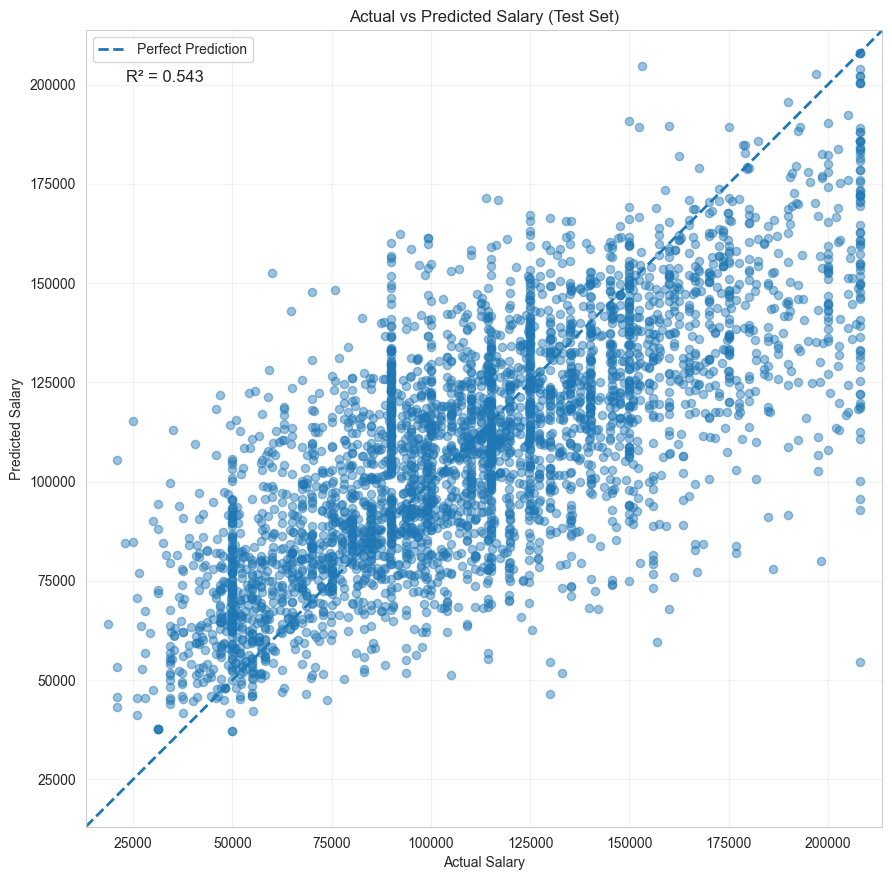

In [44]:
# ============================================================
# ACTUAL vs PREDICTED SCATTER PLOT (TEST SET ONLY)
# Run AFTER your tuning code above
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# ------------------------------------------------------------
# Generate fresh TEST predictions from tuned model
# ------------------------------------------------------------

test_pred_log = best_xgb.predict(X_test_F)

# Convert from log scale to actual salary scale
test_pred = np.expm1(test_pred_log)
test_actual = np.expm1(y_test.values)

# Convert to numpy arrays
actual_salary = np.array(test_actual)
pred_salary   = np.array(test_pred)

# ------------------------------------------------------------
# Remove invalid values
# ------------------------------------------------------------

mask = np.isfinite(actual_salary) & np.isfinite(pred_salary)

actual_salary = actual_salary[mask]
pred_salary   = pred_salary[mask]

# ------------------------------------------------------------
# Optional clipping for cleaner visualization only
# ------------------------------------------------------------

upper = np.percentile(
    np.concatenate([actual_salary, pred_salary]),
    99
)

actual_plot = np.clip(actual_salary, 0, upper)
pred_plot   = np.clip(pred_salary, 0, upper)

# ------------------------------------------------------------
# Axis range
# ------------------------------------------------------------

min_val = min(actual_plot.min(), pred_plot.min())
max_val = max(actual_plot.max(), pred_plot.max())

pad = (max_val - min_val) * 0.03

axis_min = min_val - pad
axis_max = max_val + pad

# ------------------------------------------------------------
# Compute TRUE Test R² (unclipped values)
# ------------------------------------------------------------

r2 = r2_score(actual_salary, pred_salary)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 9))

plt.scatter(
    actual_plot,
    pred_plot,
    alpha=0.45,
    s=35
)

# Perfect prediction line
plt.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlim(axis_min, axis_max)
plt.ylim(axis_min, axis_max)

plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (Test Set)")

plt.text(
    0.05,
    0.95,
    f"R² = {r2:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=12
)

plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Prediction Interval in Current XGBoost Salary Prediction

In [45]:
# ============================================================
# 95% PREDICTION INTERVALS
# RUN THIS AFTER TUNING CODE ABOVE
#
# Uses:
# - best_xgb
# - X_val_F
# - X_test_F
# - y_val
# - y_test
# - test_idx
# - df
#
# IMPORTANT:
# Model predicts salary_log
# Convert back using expm1()
# ============================================================

# ============================================================
# STEP 1: VALIDATION PREDICTIONS (CALIBRATION SET)
# ============================================================

val_pred_log = best_xgb.predict(X_val_F)

val_actual = np.expm1(y_val.values)
val_pred   = np.expm1(val_pred_log)

# absolute residuals in real salary space
val_abs_error = np.abs(val_actual - val_pred)

# ============================================================
# STEP 2: CONFORMAL ERROR QUANTILE
# ============================================================

alpha = 0.05   # 95% interval

q_hat = np.quantile(val_abs_error, 1 - alpha)

print("95% Error Quantile:", round(q_hat,2))

# ============================================================
# STEP 3: TEST SET PREDICTIONS
# ============================================================

test_pred_log = best_xgb.predict(X_test_F)

test_actual = np.expm1(y_test.values)
test_pred   = np.expm1(test_pred_log)

# ============================================================
# STEP 4: BUILD INTERVALS
# ============================================================

lower = test_pred - q_hat
upper = test_pred + q_hat

lower = np.maximum(lower, 0)

# ============================================================
# STEP 5: BUILD RESULTS DATAFRAME
# ============================================================

pi_results = df.loc[test_idx].copy()

pi_results["Actual_Salary"] = test_actual
pi_results["Predicted_Salary"] = test_pred
pi_results["PI_Lower_95"] = lower
pi_results["PI_Upper_95"] = upper

# Was true salary inside interval?
pi_results["Covered"] = (
    (pi_results["Actual_Salary"] >= pi_results["PI_Lower_95"]) &
    (pi_results["Actual_Salary"] <= pi_results["PI_Upper_95"])
).astype(int)

pi_results["Interval_Width"] = (
    pi_results["PI_Upper_95"] - pi_results["PI_Lower_95"]
)

# ============================================================
# STEP 6: SUMMARY
# ============================================================

coverage = pi_results["Covered"].mean()
avg_width = pi_results["Interval_Width"].mean()

summary = pd.DataFrame([{
    "Confidence_Level": "95%",
    "Coverage_Rate": coverage,
    "Average_Interval_Width": avg_width,
    "Median_Interval_Width": pi_results["Interval_Width"].median()
}])

display(summary)

# ============================================================
# STEP 7: SAMPLE OUTPUT
# ============================================================

display(
    pi_results[
        [
            "job_title_short",
            "job_country",
            "Actual_Salary",
            "Predicted_Salary",
            "PI_Lower_95",
            "PI_Upper_95",
            "Covered"
        ]
    ].head(20)
)

# ============================================================
# STEP 8: COVERAGE BY JOB TITLE
# ============================================================

coverage_title = (
    pi_results.groupby("job_title_short")["Covered"]
    .mean()
    .sort_values()
)

display(coverage_title)

# ============================================================
# STEP 9: COVERAGE BY COUNTRY
# ============================================================

coverage_country = (
    pi_results.groupby("job_country")["Covered"]
    .mean()
)

display(coverage_country)

95% Error Quantile: 58932.24


,Confidence_Level,Coverage_Rate,Average_Interval_Width,Median_Interval_Width
0,95%,0.953593,117542.919854,117864.476563


,job_title_short,job_country,Actual_Salary,Predicted_Salary,PI_Lower_95,PI_Upper_95,Covered
3837,Data Engineer,United States,117500.000000,102154.085938,43221.847656,161086.324219,1
148752,Data Engineer,United States,146100.000000,123128.640625,64196.402344,182060.878906,1
180540,Data Scientist,United States,175000.000000,155046.609375,96114.371094,213978.847656,1
12136,Software Engineer,United States,110219.203491,106816.539062,47884.300781,165748.777344,1
104371,Data Analyst,United States,85280.000000,92222.882812,33290.644531,151155.121094,1
124305,Senior Data Analyst,United States,95000.000000,113234.945312,54302.707031,172167.183594,1
131863,Data Scientist,United States,109200.000000,85116.546875,26184.308594,144048.785156,1
64825,Data Engineer,United States,90000.000000,105875.570312,46943.332031,164807.808594,1
221029,Data Engineer,United States,94450.000000,90145.906250,31213.667969,149078.144531,1
102001,Data Scientist,United States,170500.000000,151918.437500,92986.199219,210850.675781,1


job_title_short
Machine Learning Engineer    0.760000
Software Engineer            0.833333
Business Analyst             0.937500
Senior Data Scientist        0.939252
Data Scientist               0.942517
Data Engineer                0.958848
Data Analyst                 0.964940
Senior Data Analyst          0.972376
Senior Data Engineer         0.972727
Name: Covered, dtype: float64

job_country
Canada           0.941860
United States    0.953867
Name: Covered, dtype: float64

In [46]:
# ============================================================
# STANDARD MODEL PERFORMANCE METRICS
# ============================================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

perf = pd.DataFrame([{
    "R2": r2_score(test_actual, test_pred),
    "MAE": mean_absolute_error(test_actual, test_pred),
    "RMSE": np.sqrt(mean_squared_error(test_actual, test_pred)),
    "Coverage_95PI": coverage,
    "Avg_PI_Width": avg_width
}])

display(perf)

,R2,MAE,RMSE,Coverage_95PI,Avg_PI_Width
0,0.542581,21811.930459,28632.613491,0.953593,117542.919854


# Explainability (Best Model)

In [47]:
# SHAP
explainer = shap.TreeExplainer(best_xgb)

In [48]:
all_skills = sorted({
    skill
    for skills in df["skills_list"]
    if isinstance(skills, list)
    for skill in skills
})

print("Number of unique skills:", len(all_skills))

Number of unique skills: 214


In [49]:
eval_n = 100

np.random.seed(42)
sample_idx = np.random.choice(X_test_F.shape[0], size=eval_n, replace=False)

X_eval = X_test_F[sample_idx].toarray()

shap_values = explainer.shap_values(X_eval)
shap_interaction_values = explainer.shap_interaction_values(X_eval)

In [50]:
# ============================================================
# DEFINE FEATURES + FILTER SKILLS (FIXED ORDER)
# ============================================================

# Feature names
structured_names = list(X_train.columns)
sbert_names = [f"SBERT_{i}" for i in range(emb_train.shape[1])]
tfidf_names = list(tfidf.get_feature_names_out())

feature_names = structured_names + sbert_names + tfidf_names

# Convert to DataFrames
shap_df = pd.DataFrame(shap_values, columns=feature_names)
X_eval_df = pd.DataFrame(X_eval, columns=feature_names)

# Build skill set
skill_set = set(all_skills)

# Initial skill columns (exact match)
skill_cols = [
    col for col in feature_names
    if col.lower() in skill_set
]

print("Skills BEFORE filter:", len(skill_cols))

# Create dense test data (needed for filtering)
X_test_dense = pd.DataFrame(X_test_F.toarray(), columns=feature_names)

# ============================================================
# FILTER SKILLS (importance + test presence)
# ============================================================

importances = best_xgb.feature_importances_

MIN_IMPORTANCE = 1e-4
MIN_TEST_PRESENCE = 5

filtered_skill_cols = []

for col in skill_cols:
    feat_idx = feature_names.index(col)
    importance = importances[feat_idx]
    test_presence = (X_test_dense[col] == 1).sum()
    
    if importance >= MIN_IMPORTANCE and test_presence >= MIN_TEST_PRESENCE:
        filtered_skill_cols.append(col)

# overwrite ONCE
skill_cols = filtered_skill_cols

print("Skills AFTER filter:", len(skill_cols))
print("Sample:", skill_cols[:10])

# Final indices + subsets
skill_indices = [feature_names.index(col) for col in skill_cols]

X_eval_skills = X_eval_df[skill_cols]
shap_skills = shap_df[skill_cols]

Skills BEFORE filter: 180
Skills AFTER filter: 12
Sample: ['aws', 'azure', 'excel', 'flow', 'jira', 'python', 'sap', 'sas', 'spreadsheet', 'sql']


This code checks if the top-10 SHAP skills stay consistent across different random samples and sample sizes:
- Was used to determine the right value of `n_eval`s to use
- Shows that the results are stable and not just due to chance—makes the findings more reliable for thesis defense

In [51]:
# # ============================================================
# # SHAP SAMPLE SIZE STABILITY TEST (MULTI-SEED)
# # ============================================================

# sample_sizes = [30, 100, 200, 300, 500]
# seeds = [42, 123, 7, 2024, 99]

# results = {n: [] for n in sample_sizes}

# for n in sample_sizes:
#     for seed in seeds:
#         rng = np.random.RandomState(seed)
#         idx = rng.choice(X_test_F.shape[0], size=n, replace=False)
#         X_eval_tmp = X_test_F[idx].toarray()
        
#         shap_vals_tmp = explainer.shap_values(X_eval_tmp)
#         shap_df_tmp = pd.DataFrame(shap_vals_tmp, columns=feature_names)
        
#         shap_skills_tmp = shap_df_tmp[skill_cols]
#         importance_tmp = shap_skills_tmp.abs().mean().sort_values(ascending=False)
        
#         # store top 10 skills for this run
#         results[n].append(importance_tmp.head(10).index.tolist())

**Jaccard Stability**  
- Checks if the top-10 SHAP skills stay the same across different random samples at the same sample size ($n$).

How it works
- Run SHAP multiple times (different seeds) → get top-10 skill lists  
- Compare every pair using:

$$
J(A, B) = \frac{|A \cap B|}{|A \cup B|}
$$

In [52]:
# # ============================================================
# # JACCARD STABILITY (WITHIN SAME n)
# # ============================================================

# from itertools import combinations
# import numpy as np

# def jaccard(a, b):
#     return len(set(a) & set(b)) / len(set(a) | set(b))

# print("\nWithin-n Stability (Jaccard):")

# for n in sample_sizes:
#     pairs = list(combinations(results[n], 2))
#     overlaps = [jaccard(a, b) for a, b in pairs]
    
#     print(f"n={n}: mean={np.mean(overlaps):.3f} ± {np.std(overlaps):.3f}")

## Global SHAP

C:\Users\Raymond\AppData\Local\Temp\ipykernel_25204\1237661479.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


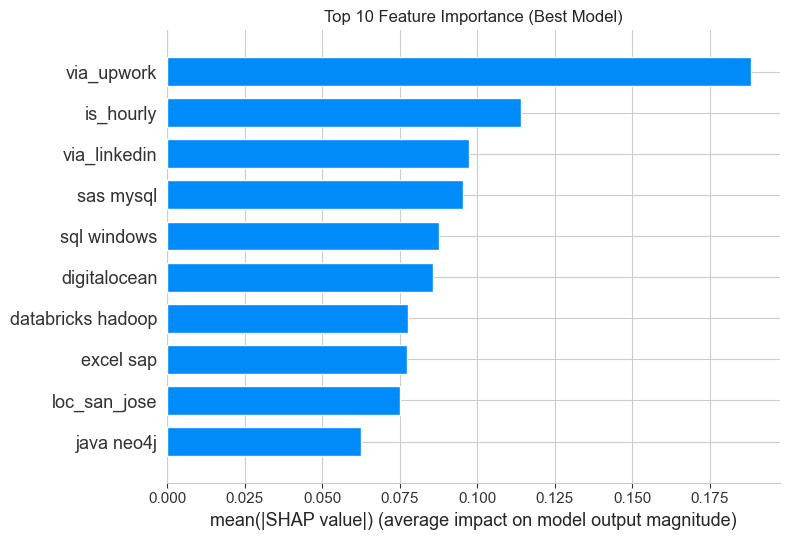

In [53]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_eval,
    feature_names=feature_names,
    plot_type="bar",
    max_display=10,
    show=False
)

plt.title("Top 10 Feature Importance (Best Model)")
plt.tight_layout()
plt.show()

This cell computes the importance of each skill using SHAP values. It calculates the average absolute SHAP value to measure how much each skill impacts salary predictions, and the mean SHAP value to show whether the effect is positive or negative. The results are combined into a dataframe, sorted by importance, and the top 20 most influential skills are displayed.

In [54]:
skill_impact_abs = shap_skills.abs().mean()
skill_impact_signed = shap_skills.mean()

skill_impact_df = pd.DataFrame({
    "Skill": skill_impact_abs.index,
    "Importance": skill_impact_abs.values,
    "Direction": skill_impact_signed.values
}).sort_values("Importance", ascending=False)

display(skill_impact_df.head(20))

,Skill,Importance,Direction
2,excel,0.022090,-0.000969
4,jira,0.009655,0.009655
9,sql,0.008151,0.004229
6,sap,0.007948,-0.007853
1,azure,0.006548,-0.006548
7,sas,0.004802,0.003618
10,tableau,0.004579,-0.003655
5,python,0.003625,-0.000020
0,aws,0.002901,0.002766
8,spreadsheet,0.002758,-0.002744


In [55]:
# ============================================================
# SELECT TOP SKILLS FOR INTERACTION ANALYSIS
# ============================================================

TOP_N = 15

top_skills = skill_impact_df.head(TOP_N)["Skill"].tolist()

print("Top skills used for interaction filtering:")
print(top_skills)

Top skills used for interaction filtering:
['excel', 'jira', 'sql', 'sap', 'azure', 'sas', 'tableau', 'python', 'aws', 'spreadsheet', 'flow', 'word']


In [56]:
interaction_matrix = shap_interaction_values[:, skill_indices, :][:, :, skill_indices]

mean_interactions = interaction_matrix.mean(axis=0)

pairs = []
for i in range(len(skill_cols)):
    for j in range(i+1, len(skill_cols)):
        pairs.append({
            "skill_1": skill_cols[i],
            "skill_2": skill_cols[j],
            "interaction": mean_interactions[i, j]
        })

interaction_pairs_df = pd.DataFrame(pairs)

top_pairs = interaction_pairs_df.reindex(
    interaction_pairs_df["interaction"].abs().sort_values(ascending=False).index
)

# ============================================================
# FILTER INTERACTIONS TO TOP SKILLS
# ============================================================

filtered_pairs = top_pairs[
    top_pairs["skill_1"].isin(top_skills) &
    top_pairs["skill_2"].isin(top_skills)
].copy()

# remove duplicates (same skill twice)
filtered_pairs = filtered_pairs[
    filtered_pairs["skill_1"] != filtered_pairs["skill_2"]
]

# select final pairs
NUM_PAIRS = 5
selected_pairs = filtered_pairs.head(NUM_PAIRS)

print("Selected pairs:")
display(selected_pairs)

display(top_pairs.head(10))

Selected pairs:


,skill_1,skill_2,interaction
24,excel,sap,-0.000869
55,sap,word,-0.000822
30,flow,jira,-0.000637
45,python,sap,0.000557
33,flow,sas,-0.000432


,skill_1,skill_2,interaction
24,excel,sap,-0.000869
55,sap,word,-0.000822
30,flow,jira,-0.000637
45,python,sap,0.000557
33,flow,sas,-0.000432
23,excel,python,-0.000275
53,sap,sql,0.000155
60,spreadsheet,sql,0.000152
38,jira,python,-0.000132
63,sql,tableau,-0.000129


In [57]:
for _, pair in selected_pairs.iterrows():
    s1, s2 = pair["skill_1"], pair["skill_2"]
    p1 = (X_test_dense[s1] == 1).sum()
    p2 = (X_test_dense[s2] == 1).sum()
    print(f"{s1} ({p1}) × {s2} ({p2})")

excel (67) × sap (5)
sap (5) × word (6)
flow (34) × jira (5)
python (59) × sap (5)
flow (34) × sas (6)


This cell verifies the selected skill pairs used for interaction analysis. It displays the pairs and counts how often each skill appears in the test set (`X_test_dense`). This ensures the skills are present enough in the data to make the interaction results reliable.

In [58]:
print("Selected pairs verification:")
display(selected_pairs)

for _, pair in selected_pairs.iterrows():
    s1, s2 = pair["skill_1"], pair["skill_2"]
    p1 = (X_test_dense[s1] == 1).sum()
    p2 = (X_test_dense[s2] == 1).sum()
    print(f"{s1} ({p1}) × {s2} ({p2})")

Selected pairs verification:


,skill_1,skill_2,interaction
24,excel,sap,-0.000869
55,sap,word,-0.000822
30,flow,jira,-0.000637
45,python,sap,0.000557
33,flow,sas,-0.000432


excel (67) × sap (5)
sap (5) × word (6)
flow (34) × jira (5)
python (59) × sap (5)
flow (34) × sas (6)


This cell plots the top 12 most important features in the model using SHAP values. It shows the average impact each feature has on salary predictions based on the sampled test data (`X_eval`). Features with higher values have a stronger influence on the model’s output, giving a clear global ranking of what drives predictions.

C:\Users\Raymond\AppData\Local\Temp\ipykernel_25204\3600705602.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


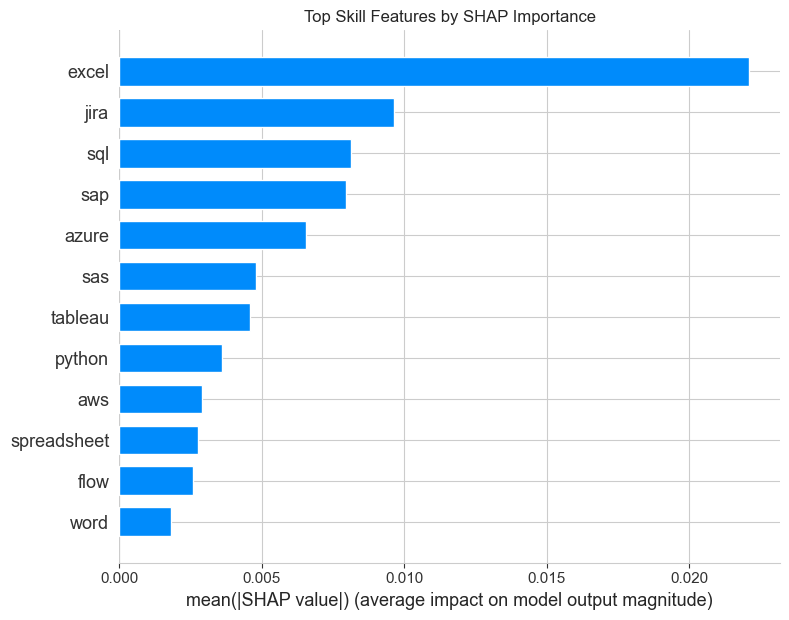

In [59]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_skills.values,
    X_eval_skills,
    feature_names=skill_cols,
    plot_type="bar",
    max_display=12,
    show=False
)

plt.title("Top Skill Features by SHAP Importance")
plt.tight_layout()

# save image
plt.savefig("Top Skill Features Affecting Salary.png", dpi=300, bbox_inches="tight")

plt.show()

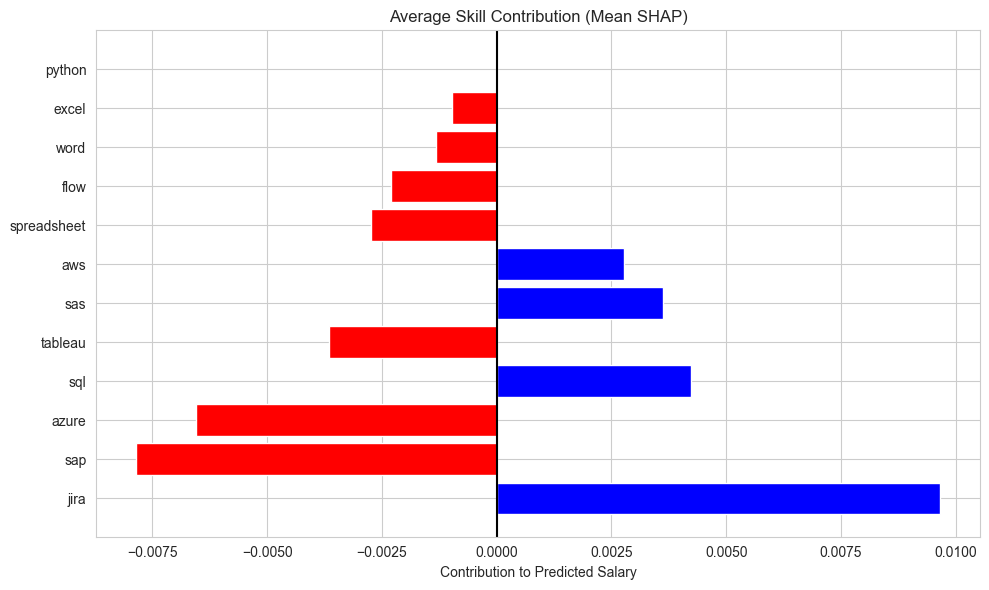

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Compute mean SHAP 
mean_shap = shap_skills.mean()

# Top 12 by importance
top_features = mean_shap.abs().sort_values(ascending=False).head(12).index
values = mean_shap[top_features]

plt.figure(figsize=(10,6))

colors = ["blue" if v > 0 else "red" for v in values]

plt.barh(values.index, values.values, color=colors)
plt.axvline(0, color='black')

plt.title("Average Skill Contribution (Mean SHAP)")
plt.xlabel("Contribution to Predicted Salary")

plt.tight_layout()
plt.savefig("mean_shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# # -----------------------------
# # 2. OPTIONAL: Waterfall-style (visual only)
# # -----------------------------
# cumulative = np.cumsum(values)

# plt.figure(figsize=(10,6))

# for i, (feat, val) in enumerate(values.items()):
#     color = "red" if val > 0 else "blue"
#     plt.barh(feat, val, left=cumulative[i] - val, color=color)

# plt.axvline(0, color='black')

# plt.title("Average Skill Contribution (Waterfall Style - Visual Only)")
# plt.xlabel("Contribution to Predicted Salary")

# plt.tight_layout()
# plt.savefig("global_waterfall_style.png", dpi=300, bbox_inches="tight")
# plt.show()

C:\Users\Raymond\AppData\Local\Temp\ipykernel_25204\1755245094.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


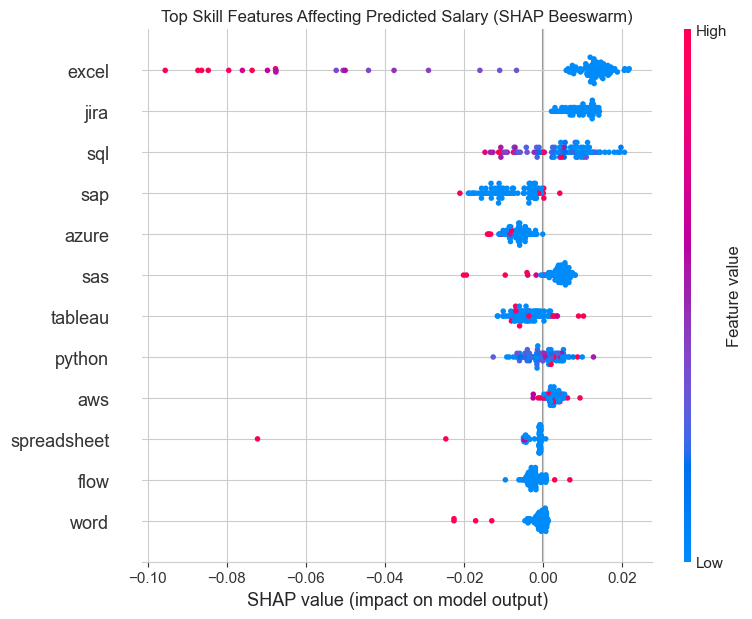

In [73]:
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_skills.values,
    X_eval_skills,
    feature_names=skill_cols,
    max_display=12,
    show=False
)

plt.title("Top Skill Features Affecting Predicted Salary (SHAP Beeswarm)")
plt.tight_layout()

plt.savefig("Top Skill Features Beeswarm.png", dpi=300, bbox_inches="tight")

plt.show()

Waterfall plot. Ignore this because it only uses it on one sample

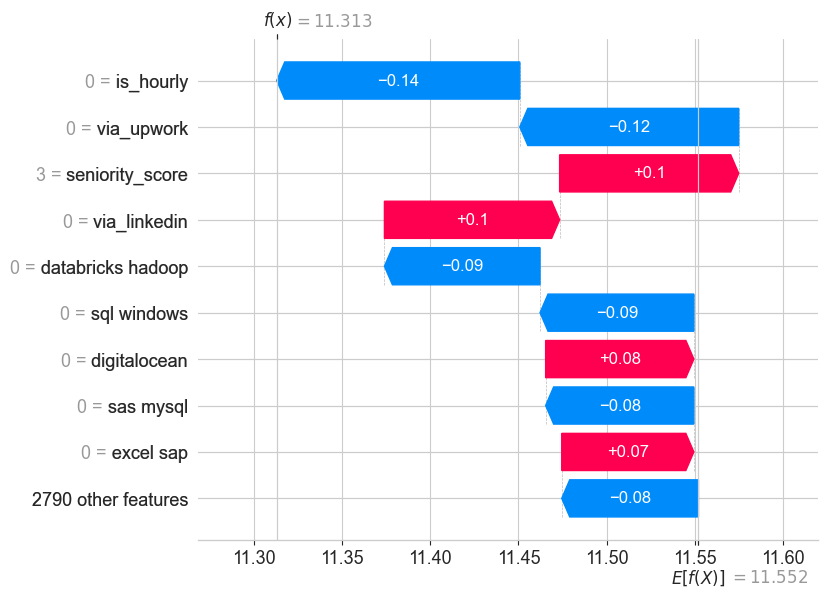

In [ ]:
# import shap

# # pick ONE sample (important)
# i = 0  

# shap.waterfall_plot(
#     shap.Explanation(
#         values=shap_values[i],
#         base_values=explainer.expected_value,
#         data=X_eval[i],
#         feature_names=feature_names
#     )
# )

## Skill Interactions

In [61]:
def get_skill_indices(skill, feature_names):
    skill_lower = skill.lower().strip()
    idx = [i for i, f in enumerate(feature_names) if f.lower() == skill_lower]
    if not idx:
        pattern = r"\b" + re.escape(skill_lower) + r"\b"
        idx = [i for i, f in enumerate(feature_names) if re.search(pattern, f.lower())]
    return idx


Analyzing: excel × sap
Mean interaction: -0.0008694739


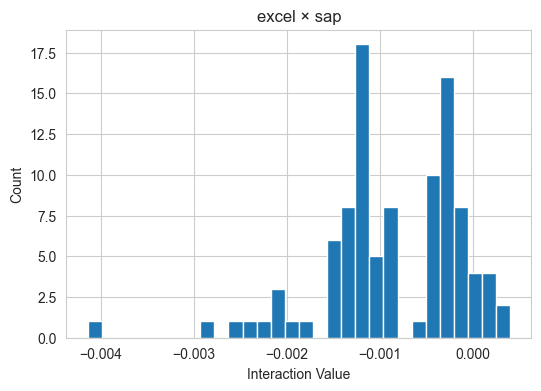


Analyzing: sap × word
Mean interaction: -0.0008221567


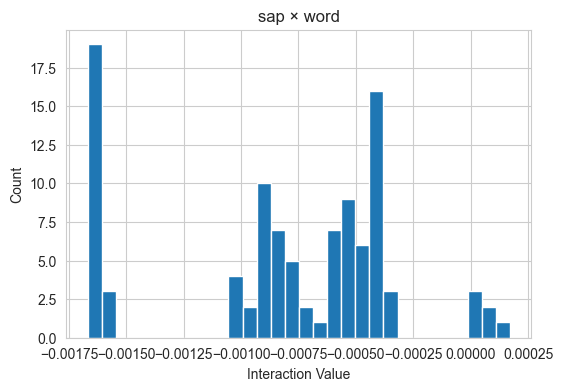


Analyzing: flow × jira
Mean interaction: -0.00063741306


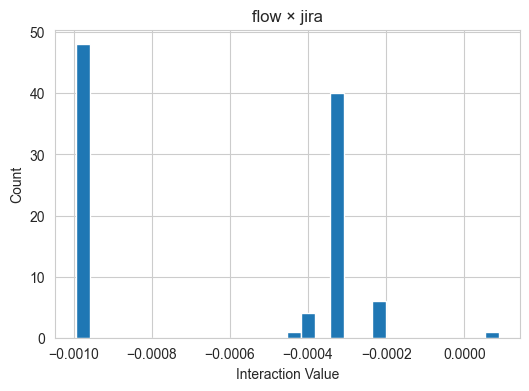


Analyzing: python × sap
Mean interaction: 0.0005573373


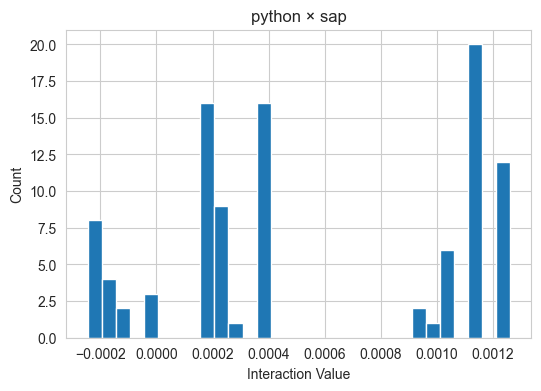


Analyzing: flow × sas
Mean interaction: -0.00043192


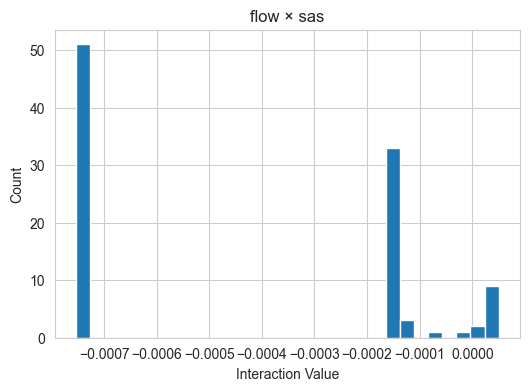

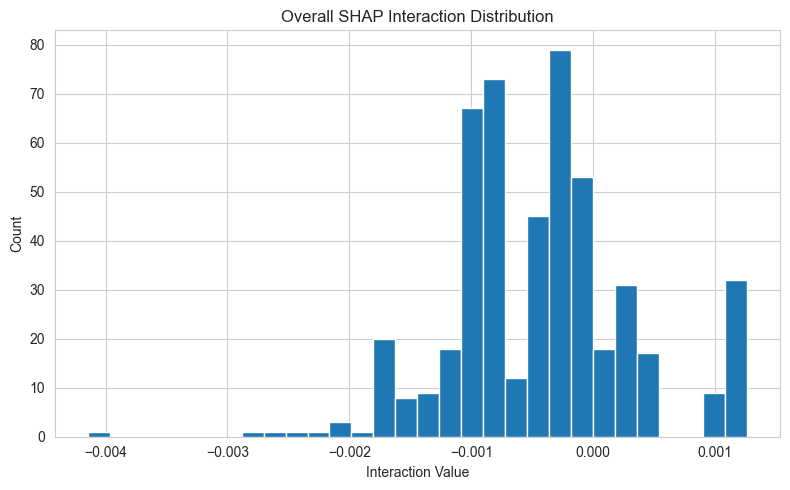

In [62]:
all_interaction_vals = []

for _, pair in selected_pairs.iterrows():

    skill_1 = pair["skill_1"]
    skill_2 = pair["skill_2"]

    print("\n======================")
    print("Analyzing:", skill_1, "×", skill_2)

    skill_1_idx = get_skill_indices(skill_1, feature_names)
    skill_2_idx = get_skill_indices(skill_2, feature_names)

    # Skip if not found
    if len(skill_1_idx) == 0 or len(skill_2_idx) == 0:
        print("Skipping (not found)")
        continue

    # Compute interaction
    interaction_vals = shap_interaction_values[:, skill_1_idx, :][:, :, skill_2_idx].mean(axis=(1,2))

    print("Mean interaction:", interaction_vals.mean())

    all_interaction_vals.extend(interaction_vals)

    # Plot per pair
    plt.figure(figsize=(6,4))
    plt.hist(interaction_vals, bins=30)
    plt.title(f"{skill_1} × {skill_2}")
    plt.xlabel("Interaction Value")
    plt.ylabel("Count")
    plt.show()


# GLOBAL DISTRIBUTION
plt.figure(figsize=(8,5))
plt.hist(all_interaction_vals, bins=30)

plt.title("Overall SHAP Interaction Distribution")
plt.xlabel("Interaction Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## EDA (before Counterfactuals)

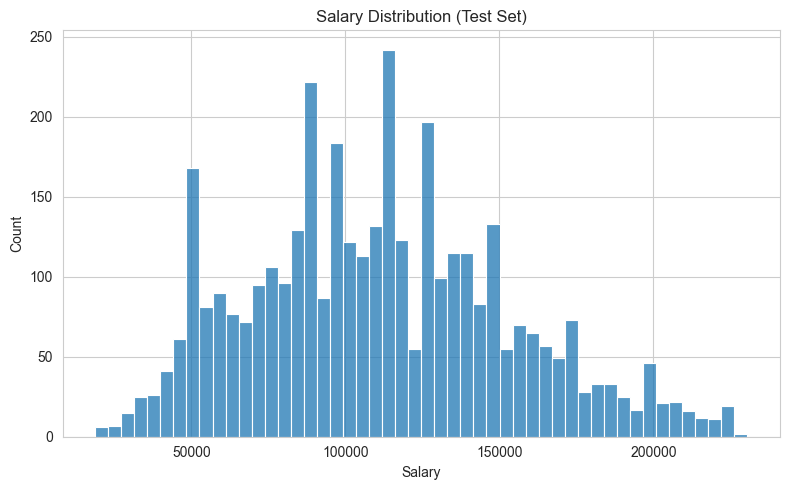

In [63]:
plt.figure(figsize=(8,5))

sns.histplot(np.expm1(y_test.values), bins=50)

plt.title("Salary Distribution (Test Set)")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Just checked the salary distribution again because my plan was that we were going to select the entries for the counterfactuals based off salary brackets so that there's more representation. It describes how the market values skills across different job levels. 

## Counterfactuals

In [64]:
# ============================================================
# COUNTERFACTUAL HELPERS
# ============================================================

def get_skill_columns(skill):
    skill_lower = skill.lower().strip()
    matches = [c for c in feature_names if c.lower() == skill_lower]
    if not matches:
        pattern = r"\b" + re.escape(skill_lower) + r"\b"
        matches = [c for c in feature_names if re.search(pattern, c.lower())]
    return matches

def add_skill(row, skill):
    row_new = row.copy()
    cols = get_skill_columns(skill)
    for c in cols:
        if row_new[c] == 0:
            row_new[c] = 1
    return row_new

**Counterfactual Sample Size Determination**

This section determines how many samples (`n`) are needed for reliable counterfactual analysis. It selects the most important skill pair and evaluates their interaction effect across different sample sizes, using a stratified approach (low, mid, high salary tiers) to ensure balanced representation. For each sample size, bootstrap resampling is applied to compute a 95% confidence interval for the interaction effect.

The key idea is that as sample size increases, the confidence interval becomes narrower, meaning the estimate is more stable and precise. By plotting confidence interval width against total sample size, we can visually identify where adding more samples gives diminishing returns. This justifies the chosen `n` for counterfactual analysis as a balance between statistical reliability and computational efficiency.

Calibrating sample size using: excel x sap


,per_tier,total_n,mean_interaction,ci_low,ci_high,ci_width,relative_width
0,10,30,22.275782,-126.079430,175.341797,301.421234,13.531343
1,25,75,-105.437447,-193.517944,-15.128771,178.389175,1.691896
2,50,150,-174.062088,-236.581070,-110.622482,125.958588,0.723642
3,100,300,-160.964188,-205.854858,-117.391220,88.463638,0.549586
4,200,600,-149.938980,-182.294525,-119.335884,62.958641,0.419895


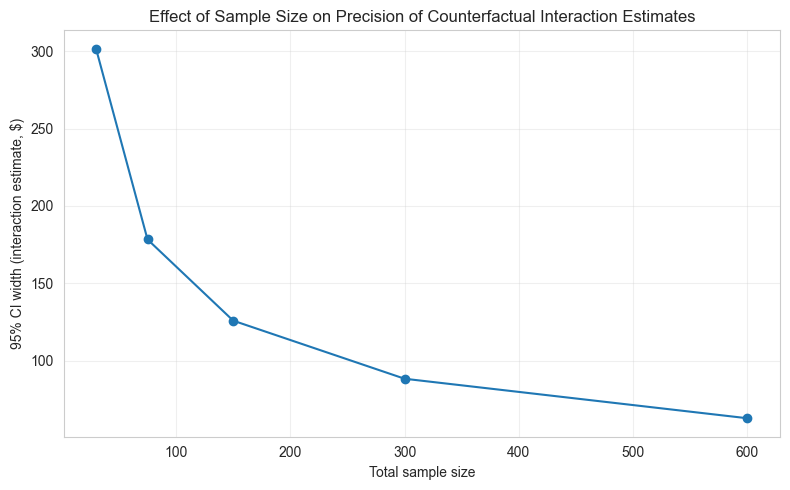

In [65]:
# ============================================================
# COUNTERFACTUAL SAMPLE SIZE DETERMINATION
# ============================================================

from scipy import stats

# pick the most important pair to calibrate on
test_skill_1 = selected_pairs.iloc[0]["skill_1"]
test_skill_2 = selected_pairs.iloc[0]["skill_2"]

print(f"Calibrating sample size using: {test_skill_1} x {test_skill_2}")

# build tier-stratified index pool from full test set
test_df_full = pd.DataFrame({"salary": np.expm1(y_test.values)})
test_df_full["bin"] = pd.qcut(test_df_full["salary"], q=3, labels=["low", "mid", "high"])

def sample_stratified(per_tier, seed):
    idx = []
    for b in ["low", "mid", "high"]:
        pool = test_df_full[test_df_full["bin"] == b].index
        chosen = np.random.RandomState(seed).choice(pool, size=per_tier, replace=False)
        idx.extend(chosen)
    return idx

def compute_interaction_for_sample(indices, s1, s2):
    gains_s1, gains_s2, interactions = [], [], []
    for i in indices:
        row = X_test_dense.iloc[i].copy()
        base = np.expm1(best_xgb.predict(row.values.reshape(1, -1))[0])
        
        s1_pred = np.expm1(best_xgb.predict(
            add_skill(row, s1).values.reshape(1, -1))[0])
        s2_pred = np.expm1(best_xgb.predict(
            add_skill(row, s2).values.reshape(1, -1))[0])
        
        both_row = add_skill(add_skill(row, s1), s2)
        both_pred = np.expm1(best_xgb.predict(both_row.values.reshape(1, -1))[0])
        
        g1 = s1_pred - base
        g2 = s2_pred - base
        gains_s1.append(g1)
        gains_s2.append(g2)
        interactions.append((both_pred - base) - (g1 + g2))
    return np.array(gains_s1), np.array(gains_s2), np.array(interactions)

# sweep sample sizes per tier
per_tier_sizes = [10, 25, 50, 100, 200]
n_bootstrap = 1000
results = []

for per_tier in per_tier_sizes:
    # limit per_tier to available tier size
    max_available = test_df_full["bin"].value_counts().min()
    if per_tier > max_available:
        print(f"Skipping {per_tier} (only {max_available} available per tier)")
        continue
    
    indices = sample_stratified(per_tier, seed=42)
    g1, g2, inter = compute_interaction_for_sample(indices, test_skill_1, test_skill_2)
    
    # bootstrap 95% CI for each quantity
    def boot_ci(arr):
        means = [np.mean(np.random.choice(arr, size=len(arr), replace=True))
                 for _ in range(n_bootstrap)]
        return np.percentile(means, 2.5), np.percentile(means, 97.5)
    
    inter_lo, inter_hi = boot_ci(inter)
    
    results.append({
        "per_tier": per_tier,
        "total_n": len(indices),
        "mean_interaction": inter.mean(),
        "ci_low": inter_lo,
        "ci_high": inter_hi,
        "ci_width": inter_hi - inter_lo,
        "relative_width": (inter_hi - inter_lo) / abs(inter.mean()) if inter.mean() != 0 else np.nan
    })

sample_size_df = pd.DataFrame(results)
display(sample_size_df)

# plot CI width vs n
plt.figure(figsize=(8, 5))
plt.plot(sample_size_df["total_n"], sample_size_df["ci_width"], marker="o")
plt.xlabel("Total sample size")
plt.ylabel("95% CI width (interaction estimate, $)")
plt.title("Effect of Sample Size on Precision of Counterfactual Interaction Estimates")
plt.grid(alpha=0.3)
plt.tight_layout()

# save image
plt.savefig("counterfactual_sample_size_vs_precision.png", dpi=300, bbox_inches="tight")

plt.show()

## Counterfactuals One Sample (for experimenting purposes only, do not include in paper)

This is an illustrative example of a single job profile. Final conclusions are based on aggregated results.

In [66]:
# pick ONE sample
row = X_test_dense.iloc[0].copy()

# pick ONE pair (just for demo)
skill_1 = selected_pairs.iloc[0]["skill_1"]
skill_2 = selected_pairs.iloc[0]["skill_2"]

print("Using skills:", skill_1, "and", skill_2)

# base prediction
base_pred_log = best_xgb.predict(row.values.reshape(1, -1))[0]
base_salary = np.expm1(base_pred_log)

print("Base salary:", base_salary)

# skill 1
row_s1 = add_skill(row, skill_1)
s1 = np.expm1(best_xgb.predict(row_s1.values.reshape(1,-1))[0])
s1_gain = s1 - base_salary

# skill 2
row_s2 = add_skill(row, skill_2)
s2 = np.expm1(best_xgb.predict(row_s2.values.reshape(1,-1))[0])
s2_gain = s2 - base_salary

# both
row_both = add_skill(row, skill_1)
row_both = add_skill(row_both, skill_2)
both = np.expm1(best_xgb.predict(row_both.values.reshape(1,-1))[0])
both_gain = both - base_salary

# interaction
expected = s1_gain + s2_gain
interaction = both_gain - expected

# print results
print(f"{skill_1} gain:", s1_gain)
print(f"{skill_2} gain:", s2_gain)
print("Both gain:", both_gain)
print("Expected (additive):", expected)
print("Interaction:", interaction)

Using skills: excel and sap
Base salary: 64116.086
excel gain: 0.0
sap gain: 1848.5703
Both gain: 1848.5703
Expected (additive): 1848.5703
Interaction: 0.0


## Aggregated Results (Final, include this in paper)

In [67]:
test_df = pd.DataFrame({
    "salary": np.expm1(y_test.values)
})

test_df["bin"] = pd.qcut(
    test_df["salary"],
    q=3,
    labels=["low", "mid", "high"]
)

PER_TIER_N = 100  # gives total_n ≈ 300

sample_indices = []

for b in ["low", "mid", "high"]:
    idx = test_df[test_df["bin"] == b].sample(PER_TIER_N, random_state=42).index
    sample_indices.extend(idx)

In [68]:
def boot_ci(arr, n=1000):
    means = [
        np.mean(np.random.choice(arr, size=len(arr), replace=True))
        for _ in range(n)
    ]
    return np.percentile(means, 2.5), np.percentile(means, 97.5)

In [69]:
all_results = []

for _, pair in selected_pairs.iterrows():

    skill_1 = pair["skill_1"]
    skill_2 = pair["skill_2"]

    print("\n======================")
    print("Skills:", skill_1, "and", skill_2)

    results = []

    for i in sample_indices:
        row = X_test_dense.iloc[i].copy()

        base = np.expm1(best_xgb.predict(row.values.reshape(1,-1))[0])

        # skill 1
        row_s1 = add_skill(row, skill_1)
        s1 = np.expm1(best_xgb.predict(row_s1.values.reshape(1,-1))[0])

        # skill 2
        row_s2 = add_skill(row, skill_2)
        s2 = np.expm1(best_xgb.predict(row_s2.values.reshape(1,-1))[0])

        # both
        row_both = add_skill(row, skill_1)
        row_both = add_skill(row_both, skill_2)
        both = np.expm1(best_xgb.predict(row_both.values.reshape(1,-1))[0])

        skill_1_gain = s1 - base
        skill_2_gain = s2 - base
        both_gain = both - base

        expected = skill_1_gain + skill_2_gain
        interaction = both_gain - expected

        results.append({
            "skill_1_gain": skill_1_gain,
            "skill_2_gain": skill_2_gain,
            "interaction": interaction
        })

    interaction_df = pd.DataFrame(results)

    print("\nSummary:")
    display(interaction_df.describe())

    # -------------------------
    # Tier analysis
    # -------------------------
    interaction_df["tier"] = test_df.loc[sample_indices, "bin"].values

    grouped = interaction_df.groupby("tier", observed=True)[[
        "skill_1_gain",
        "skill_2_gain",
        "interaction"
    ]].mean()

    grouped.columns = [
        f"{skill_1} Gain",
        f"{skill_2} Gain",
        "Interaction"
    ]

    print("\nTier Analysis:")
    display(grouped)

    # -------------------------
    # Summary stats
    # -------------------------
    avg_s1 = interaction_df["skill_1_gain"].mean()
    avg_s2 = interaction_df["skill_2_gain"].mean()
    avg_interaction = interaction_df["interaction"].mean()

    # -------------------------
    # BOOTSTRAP (CORRECT PLACEMENT)
    # -------------------------
    inter_lo, inter_hi = boot_ci(interaction_df["interaction"].values)

    print(f"\nMean interaction: {avg_interaction:.2f} (95% CI: [{inter_lo:.2f}, {inter_hi:.2f}])")

    if inter_lo > 0:
        print("Significantly positive interaction (synergy)")
    elif inter_hi < 0:
        print("Significantly negative interaction (diminishing returns)")
    else:
        print("Interaction not statistically distinguishable from zero")

    # -------------------------
    # Skill effects
    # -------------------------
    print(f"{skill_1} increases predicted salary by approx: {avg_s1:.2f}")
    print(f"{skill_2} increases predicted salary by approx: {avg_s2:.2f}")

    if avg_interaction < 0:
        print("Negative interaction (diminishing returns)")
    else:
        print("Positive interaction (synergy)")

    # -------------------------
    # Store results
    # -------------------------
    all_results.append({
        "skill_1": skill_1,
        "skill_2": skill_2,
        "avg_s1_gain": avg_s1,
        "avg_s2_gain": avg_s2,
        "avg_interaction": avg_interaction,
        "ci_low": inter_lo,
        "ci_high": inter_hi
    })

# Final table
interaction_summary = pd.DataFrame(all_results)
display(interaction_summary)


Skills: excel and sap

Summary:


,skill_1_gain,skill_2_gain,interaction
count,300.000000,300.000000,300.000000
mean,-4478.037598,2542.472900,-160.964188
std,3529.145752,1538.825562,380.623566
min,-16037.281250,-319.101562,-1223.367188
25%,-7002.279297,1473.355469,-417.207031
50%,-4347.023438,2258.019531,-22.285156
75%,-1122.626953,3366.076172,1.130859
max,823.078125,7604.882812,1508.148438



Tier Analysis:


,excel Gain,sap Gain,Interaction
tier,,,
low,-4027.815430,2334.181885,-149.895630
mid,-4679.180176,2589.932129,-156.365738
high,-4727.116211,2703.304688,-176.631210



Mean interaction: -160.96 (95% CI: [-202.30, -120.03])
Significantly negative interaction (diminishing returns)
excel increases predicted salary by approx: -4478.04
sap increases predicted salary by approx: 2542.47
Negative interaction (diminishing returns)

Skills: sap and word

Summary:


...

,skill_1_gain,skill_2_gain,interaction
count,300.000000,300.000000,300.000000
mean,-260.095245,-841.300964,-162.382538
std,870.797058,881.980896,164.591629
min,-3663.179688,-3664.320312,-443.750000
25%,-794.846680,-1338.847656,-312.517578
50%,-92.976562,-757.050781,-216.646484
75%,381.792969,-204.220703,0.000000
max,2492.117188,1048.484375,219.984375



Tier Analysis:


,flow Gain,sas Gain,Interaction
tier,,,
low,-391.904694,-797.007629,-199.186249
mid,-222.688828,-768.731873,-140.600662
high,-165.692230,-958.163147,-147.360703



Mean interaction: -162.38 (95% CI: [-180.44, -144.53])
Significantly negative interaction (diminishing returns)
flow increases predicted salary by approx: -260.10
sas increases predicted salary by approx: -841.30
Negative interaction (diminishing returns)


,skill_1,skill_2,avg_s1_gain,avg_s2_gain,avg_interaction,ci_low,ci_high
0,excel,sap,-4478.037598,2542.472900,-160.964188,-202.304581,-120.025452
1,sap,word,2542.472900,-2620.598633,-223.517166,-248.959869,-199.806427
2,flow,jira,-260.095245,-1247.385010,-97.402435,-110.945534,-83.415428
3,python,sap,-289.123535,2542.472900,90.687134,76.414635,105.442535
4,flow,sas,-260.095245,-841.300964,-162.382538,-180.444931,-144.527298


# Ignore this (for diagnostic purposes only)

In [70]:
print("Selected pairs after filtering:")
display(selected_pairs)

for _, pair in selected_pairs.iterrows():
    s1, s2 = pair["skill_1"], pair["skill_2"]
    p1 = (X_test_dense[s1] == 1).sum()
    p2 = (X_test_dense[s2] == 1).sum()
    print(f"{s1} ({p1}/{len(X_test_dense)}) × {s2} ({p2}/{len(X_test_dense)})")

Selected pairs after filtering:


,skill_1,skill_2,interaction
24,excel,sap,-0.000869
55,sap,word,-0.000822
30,flow,jira,-0.000637
45,python,sap,0.000557
33,flow,sas,-0.000432


excel (67/3771) × sap (5/3771)
sap (5/3771) × word (6/3771)
flow (34/3771) × jira (5/3771)
python (59/3771) × sap (5/3771)
flow (34/3771) × sas (6/3771)
